# Fase 3 - Análisis exploratorio (EDA) y KPIs

**Entrada:** `data/clean/pedidos.csv` e `items.csv` (salida de la fase 2).

**Preguntas:**
1. ¿Cuánto vende el negocio y cómo evoluciona?
2. ¿Qué se vende y dónde?
3. ¿Repiten los clientes?
4. ¿Qué tal es la experiencia (entrega y valoración)?
5. ¿Qué relación hay entre la experiencia y la valoración?

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

pedidos = pd.read_csv("../data/clean/pedidos.csv",
                      parse_dates=["order_purchase_timestamp", "order_delivered_customer_date"])
items = pd.read_csv("../data/clean/items.csv")

AZUL = "#3b6ea5"

def estilo(eje, titulo):
    """Aspecto común de todos los gráficos: título a la izquierda y sin marco."""
    eje.set_title(titulo, loc="left", fontsize=11)
    eje.spines[["top", "right"]].set_visible(False)

pedidos.shape

(96203, 23)

## 1. KPIs generales
Un KPI es una cifra que resume cómo va algo que le importa al negocio.

In [2]:
pedidos_por_cliente = pedidos.groupby("customer_unique_id")["order_id"].count()

# "mala_nota": 1 o 2 estrellas. Se deja nulo si el pedido no tiene valoración.
pedidos["mala_nota"] = (pedidos["review_score"] <= 2).where(pedidos["review_score"].notna())

kpis = pd.Series({
    "Pedidos": len(pedidos),
    "Clientes únicos": pedidos["customer_unique_id"].nunique(),
    "Ingresos (reales)": pedidos["valor_total"].sum(),
    "Ticket medio (reales)": pedidos["valor_total"].mean(),
    "Ticket mediano (reales)": pedidos["valor_total"].median(),
    "Productos por pedido": pedidos["n_items"].mean(),
    "Peso del envío sobre el total (%)": 100 * pedidos["valor_envio"].sum() / pedidos["valor_total"].sum(),
    "Clientes que repiten (%)": 100 * (pedidos_por_cliente >= 2).mean(),
    "Plazo medio de entrega (días)": pedidos["dias_entrega"].mean(),
    "Pedidos con retraso (%)": 100 * pedidos["con_retraso"].mean(),
    "Nota media (1-5)": pedidos["review_score"].mean(),
    "Pedidos con mala nota (%)": 100 * pedidos["mala_nota"].mean(),
}).round(2)
kpis

Pedidos                                 96203.00
Clientes únicos                         93096.00
Ingresos (reales)                    15376430.99
Ticket medio (reales)                     159.83
Ticket mediano (reales)                   105.28
Productos por pedido                        1.14
Peso del envío sobre el total (%)          14.29
Clientes que repiten (%)                    3.00
Plazo medio de entrega (días)              12.54
Pedidos con retraso (%)                     8.13
Nota media (1-5)                            4.16
Pedidos con mala nota (%)                  12.80
dtype: float64

## 2. Evolución mensual

In [3]:
pedidos["mes"] = pedidos["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()

mensual = pedidos.groupby("mes").agg(
    pedidos=("order_id", "count"),
    ingresos=("valor_total", "sum"),
    ticket_medio=("valor_total", "mean"),
    nota_media=("review_score", "mean"),
    pct_retraso=("con_retraso", "mean"),
)
mensual["pct_retraso"] = 100 * mensual["pct_retraso"]
mensual.round(2)

,pedidos,ingresos,ticket_medio,nota_media,pct_retraso
mes,,,,,
2017-01-01,750,127482.37,169.98,4.20,3.07
2017-02-01,1653,271239.32,164.09,4.20,3.21
2017-03-01,2546,414330.95,162.74,4.19,5.58
2017-04-01,2303,390812.40,169.70,4.14,7.86
2017-05-01,3545,566657.40,159.85,4.24,3.61
2017-06-01,3135,490050.37,156.32,4.22,3.86
2017-07-01,3872,566299.08,146.25,4.26,3.43
2017-08-01,4193,645915.12,154.05,4.31,3.32
2017-09-01,4150,701077.49,168.93,4.27,5.20


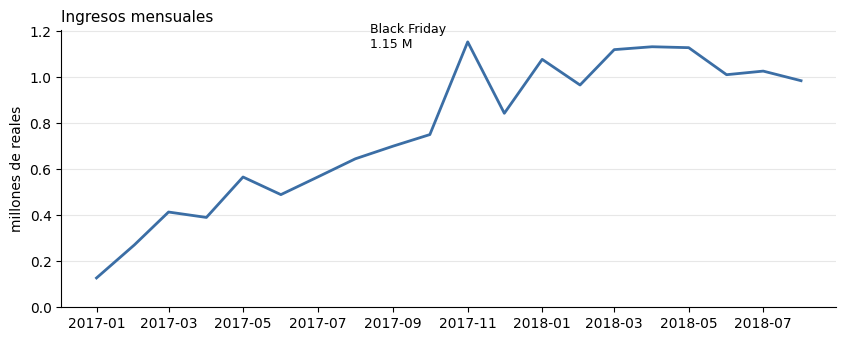

In [4]:
fig, eje = plt.subplots(figsize=(10, 3.6))
eje.plot(mensual.index, mensual["ingresos"] / 1e6, color=AZUL, linewidth=2)

# Etiqueta solo en el pico, no en todos los puntos
pico = mensual["ingresos"].idxmax()
eje.annotate(f"Black Friday\n{mensual.loc[pico, 'ingresos'] / 1e6:.2f} M",
             xy=(pico, mensual.loc[pico, "ingresos"] / 1e6),
             xytext=(-70, -4), textcoords="offset points", fontsize=9)

eje.set_ylim(0)
eje.set_ylabel("millones de reales")
eje.grid(axis="y", alpha=0.3)
estilo(eje, "Ingresos mensuales")
plt.show()

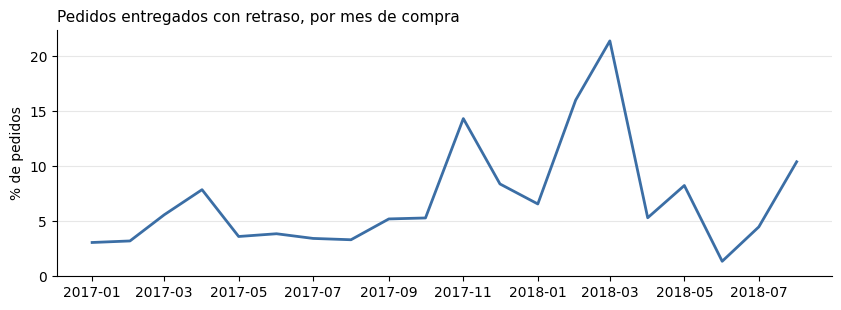

In [5]:
fig, eje = plt.subplots(figsize=(10, 3.2))
eje.plot(mensual.index, mensual["pct_retraso"], color=AZUL, linewidth=2)
eje.set_ylim(0)
eje.set_ylabel("% de pedidos")
eje.grid(axis="y", alpha=0.3)
estilo(eje, "Pedidos entregados con retraso, por mes de compra")
plt.show()

## 3. Qué se vende: categorías

In [6]:
categorias = items.groupby("categoria").agg(
    unidades=("order_item_id", "count"),
    ingresos=("price", "sum"),
    precio_medio=("price", "mean"),
).sort_values("ingresos", ascending=False)

categorias["pct_ingresos"] = 100 * categorias["ingresos"] / categorias["ingresos"].sum()
categorias["pct_acumulado"] = categorias["pct_ingresos"].cumsum()

print("Categorías en total:", len(categorias))
categorias.head(10).round(1)

Categorías en total: 74


,unidades,ingresos,precio_medio,pct_ingresos,pct_acumulado
categoria,,,,,
Salud y belleza,9422,1229557.5,130.5,9.3,9.3
Relojes y regalos,5853,1163187.9,198.7,8.8,18.2
"Cama, baño y mesa",10945,1022955.8,93.5,7.8,25.9
Deporte y ocio,8413,952661.4,113.2,7.2,33.1
Informática y accesorios,7631,887944.6,116.4,6.7,39.9
Muebles y decoración,8095,706237.2,87.2,5.4,45.2
Menaje del hogar,6783,614341.6,90.6,4.7,49.9
Artículos originales,3711,609158.0,164.1,4.6,54.5
Automóvil,4131,577721.1,139.9,4.4,58.9


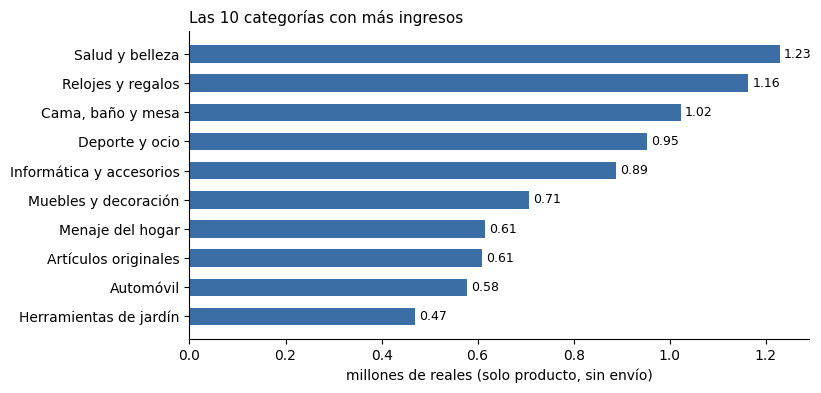

In [7]:
top = categorias.head(10).sort_values("ingresos")       # de menor a mayor para que la mayor quede arriba

fig, eje = plt.subplots(figsize=(8, 4))
barras = eje.barh(top.index, top["ingresos"] / 1e6, color=AZUL, height=0.6)
eje.bar_label(barras, fmt="%.2f", padding=3, fontsize=9)
eje.set_xlabel("millones de reales (solo producto, sin envío)")
estilo(eje, "Las 10 categorías con más ingresos")
plt.show()

## 4. Dónde se vende: estados

In [8]:
estados = pedidos.groupby("customer_state").agg(
    pedidos=("order_id", "count"),
    ingresos=("valor_total", "sum"),
    ticket_medio=("valor_total", "mean"),
    envio_medio=("valor_envio", "mean"),
    dias_entrega=("dias_entrega", "mean"),
    pct_retraso=("con_retraso", "mean"),
    nota_media=("review_score", "mean"),
).sort_values("ingresos", ascending=False)

estados["pct_ingresos"] = 100 * estados["ingresos"] / estados["ingresos"].sum()
estados["pct_retraso"] = 100 * estados["pct_retraso"]
estados.head(10).round(1)

,pedidos,ingresos,ticket_medio,envio_medio,dias_entrega,pct_retraso,nota_media,pct_ingresos
customer_state,,,,,,,,
SP,40399,5756825.6,142.5,17.4,8.7,5.9,4.2,37.4
RJ,12310,2046592.2,166.3,24.0,15.3,13.5,4.0,13.3
MG,11319,1814420.2,160.3,23.5,12.0,5.6,4.2,11.8
RS,5327,858642.9,161.2,24.9,15.3,7.2,4.2,5.6
PR,4903,779356.3,159.0,23.5,12.0,5.0,4.2,5.1
SC,3537,592634.7,167.6,24.8,14.9,9.8,4.1,3.9
BA,3253,590816.8,181.6,30.0,19.3,14.0,3.9,3.8
DF,2074,345228.8,166.5,24.0,12.9,7.1,4.1,2.2
GO,1950,333606.4,171.1,26.5,15.6,8.2,4.1,2.2


Los estados con peor entrega (con al menos 500 pedidos):

In [9]:
estados[estados["pedidos"] >= 500].sort_values("dias_entrega", ascending=False).head(5).round(1)

,pedidos,ingresos,ticket_medio,envio_medio,dias_entrega,pct_retraso,nota_media,pct_ingresos
customer_state,,,,,,,,
PA,942,210740.5,223.7,39.7,23.8,12.4,3.9,1.4
MA,713,146804.7,205.9,42.8,21.5,19.6,3.8,1.0
CE,1273,264707.8,207.9,36.6,21.2,15.4,3.9,1.7
PB,516,137763.8,267.0,48.9,20.4,11.0,4.1,0.9
BA,3253,590816.8,181.6,30.0,19.3,14.0,3.9,3.8


## 5. Clientes: ¿repiten?

In [10]:
recompra = pedidos_por_cliente.clip(upper=4).value_counts().sort_index()
recompra.index = ["1 pedido", "2 pedidos", "3 pedidos", "4 o más"]

tabla_recompra = pd.DataFrame({"clientes": recompra,
                               "pct": (100 * recompra / recompra.sum()).round(2)})
tabla_recompra

,clientes,pct
1 pedido,90307,97.00
2 pedidos,2562,2.75
3 pedidos,180,0.19
4 o más,47,0.05


In [11]:
# ¿Cuánto ingresa un cliente que repite frente a uno que no?
gasto_cliente = pedidos.groupby("customer_unique_id").agg(
    pedidos=("order_id", "count"), gasto=("valor_total", "sum"))
gasto_cliente["repite"] = gasto_cliente["pedidos"] >= 2

resumen = gasto_cliente.groupby("repite").agg(clientes=("gasto", "count"),
                                              gasto_medio=("gasto", "mean"),
                                              gasto_total=("gasto", "sum"))
resumen["pct_ingresos"] = 100 * resumen["gasto_total"] / resumen["gasto_total"].sum()
resumen.round(1)

,clientes,gasto_medio,gasto_total,pct_ingresos
repite,,,,
False,90307,160.7,14515130.6,94.4
True,2789,308.8,861300.4,5.6


## 6. Experiencia: valoraciones

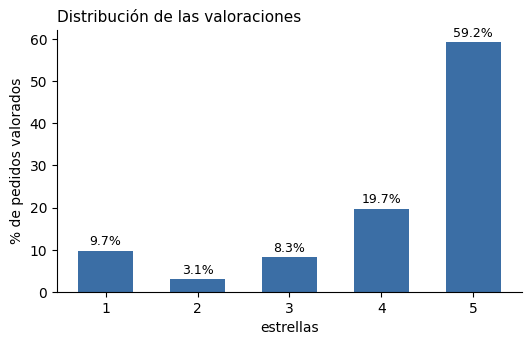

In [12]:
notas = pedidos["review_score"].value_counts(normalize=True).sort_index() * 100

fig, eje = plt.subplots(figsize=(6, 3.4))
barras = eje.bar(notas.index.astype(int).astype(str), notas.values, color=AZUL, width=0.6)
eje.bar_label(barras, fmt="%.1f%%", padding=2, fontsize=9)
eje.set_xlabel("estrellas")
eje.set_ylabel("% de pedidos valorados")
estilo(eje, "Distribución de las valoraciones")
plt.show()

## 7. ¿Qué acompaña a las malas valoraciones?

### 7.1 Retraso en la entrega
`pd.cut` trocea una columna numérica en tramos.

In [13]:
pedidos["tramo_entrega"] = pd.cut(
    pedidos["dias_vs_estimado"],
    bins=[-float("inf"), 0, 3, 7, float("inf")],
    labels=["A tiempo", "1-3 días tarde", "4-7 días tarde", "Más de 7 días tarde"])

por_retraso = pedidos.groupby("tramo_entrega", observed=True).agg(
    pedidos=("order_id", "count"),
    nota_media=("review_score", "mean"),
    pct_mala_nota=("mala_nota", "mean"))
por_retraso["pct_mala_nota"] = 100 * por_retraso["pct_mala_nota"].astype(float)
por_retraso.round(2)

,pedidos,nota_media,pct_mala_nota
tramo_entrega,,,
A tiempo,88381,4.29,9.20
1-3 días tarde,2660,3.77,19.13
4-7 días tarde,1819,2.32,61.31
Más de 7 días tarde,3343,1.73,78.43


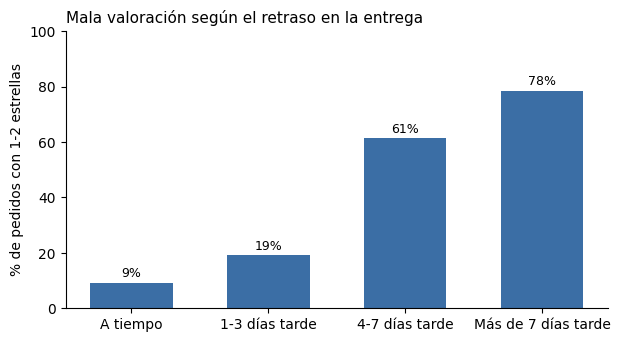

In [14]:
fig, eje = plt.subplots(figsize=(7, 3.6))
barras = eje.bar(por_retraso.index.astype(str), por_retraso["pct_mala_nota"], color=AZUL, width=0.6)
eje.bar_label(barras, fmt="%.0f%%", padding=2, fontsize=9)
eje.set_ylabel("% de pedidos con 1-2 estrellas")
eje.set_ylim(0, 100)
estilo(eje, "Mala valoración según el retraso en la entrega")
plt.show()

### 7.2 Plazo total, aunque llegue a tiempo
¿Importa tardar mucho si se cumple la fecha prometida? Miramos solo los pedidos **a tiempo**.

In [15]:
a_tiempo = pedidos[~pedidos["con_retraso"]].copy()
a_tiempo["tramo_plazo"] = pd.cut(a_tiempo["dias_entrega"], bins=[0, 7, 14, 21, 30, 400],
                                 labels=["0-7 días", "8-14", "15-21", "22-30", "Más de 30"])
tabla = a_tiempo.groupby("tramo_plazo", observed=True).agg(
    pedidos=("order_id", "count"), nota_media=("review_score", "mean"), pct_mala_nota=("mala_nota", "mean"))
tabla["pct_mala_nota"] = 100 * tabla["pct_mala_nota"].astype(float)
tabla.round(2)

,pedidos,nota_media,pct_mala_nota
tramo_plazo,,,
0-7 días,25810,4.42,7.44
8-14,39591,4.32,8.74
15-21,16800,4.18,10.70
22-30,5383,3.96,14.50
Más de 30,797,3.67,21.76


### 7.3 Pedidos con varios productos o varios vendedores

In [16]:
pedidos["tipo_pedido"] = "1 producto"
pedidos.loc[pedidos["n_items"] >= 2, "tipo_pedido"] = "Varios productos, 1 vendedor"
pedidos.loc[pedidos["n_vendedores"] >= 2, "tipo_pedido"] = "Varios vendedores"

tabla = pedidos.groupby("tipo_pedido").agg(
    pedidos=("order_id", "count"), nota_media=("review_score", "mean"),
    pct_mala_nota=("mala_nota", "mean"), pct_retraso=("con_retraso", "mean"))
tabla[["pct_mala_nota", "pct_retraso"]] = 100 * tabla[["pct_mala_nota", "pct_retraso"]].astype(float)
tabla.round(2)

,pedidos,nota_media,pct_mala_nota,pct_retraso
tipo_pedido,,,,
1 producto,86598,4.21,11.26,8.31
"Varios productos, 1 vendedor",8333,3.75,23.60,7.32
Varios vendedores,1272,2.86,47.14,1.42


### 7.4 Correlaciones
La correlación va de -1 a 1. Cerca de 0 significa que no hay relación lineal.
Ojo: correlación no implica causa.

In [17]:
(pedidos[["review_score", "dias_entrega", "dias_vs_estimado", "valor_total", "valor_envio", "n_items", "n_vendedores"]]
 .corr()["review_score"].drop("review_score").sort_values().round(3))

dias_entrega       -0.334
dias_vs_estimado   -0.270
n_items            -0.123
n_vendedores       -0.116
valor_envio        -0.089
valor_total        -0.042
Name: review_score, dtype: float64

## 8. ¿Cuánto del problema explica el retraso?

In [18]:
malas = pedidos[pedidos["mala_nota"] == True]
print(f"Pedidos con mala nota:              {len(malas):,}")
print(f"  de ellos, entregados con retraso: {malas['con_retraso'].sum():,} ({malas['con_retraso'].mean():.1%})")
print(f"  de ellos, entregados a tiempo:    {(~malas['con_retraso']).sum():,} ({(~malas['con_retraso']).mean():.1%})")

Pedidos con mala nota:              12,228
  de ellos, entregados con retraso: 4,140 (33.9%)
  de ellos, entregados a tiempo:    8,088 (66.1%)
